In [1]:
# importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

In [2]:
# Importación de Archivo CSV (Comma-Separated Values)

datos_csv = pd.read_csv(r"C:\Users\orlan\OneDrive\Documents\Tecnicatura\2A1C - Aprendizaje Automatico\Semana 4\FINAL_USO.csv", encoding= "ISO-8859-1")
print("#1 Archivo CSV")
datos_csv.head()

#1 Archivo CSV


,Date,Open,High,Low,Close,Adj Close,Volume,SP_open,SP_high,SP_low,...,GDX_Low,GDX_Close,GDX_Adj Close,GDX_Volume,USO_Open,USO_High,USO_Low,USO_Close,USO_Adj Close,USO_Volume
0,2011-12-15,154.740005,154.949997,151.710007,152.330002,152.330002,21521900,123.029999,123.199997,121.989998,...,51.570000,51.680000,48.973877,20605600,36.900002,36.939999,36.049999,36.130001,36.130001,12616700
1,2011-12-16,154.309998,155.369995,153.899994,155.229996,155.229996,18124300,122.230003,122.949997,121.300003,...,52.040001,52.680000,49.921513,16285400,36.180000,36.500000,35.730000,36.270000,36.270000,12578800
2,2011-12-19,155.479996,155.860001,154.360001,154.869995,154.869995,12547200,122.059998,122.320000,120.029999,...,51.029999,51.169998,48.490578,15120200,36.389999,36.450001,35.930000,36.200001,36.200001,7418200
3,2011-12-20,156.820007,157.429993,156.580002,156.979996,156.979996,9136300,122.180000,124.139999,120.370003,...,52.369999,52.990002,50.215282,11644900,37.299999,37.610001,37.220001,37.560001,37.560001,10041600
4,2011-12-21,156.979996,157.529999,156.130005,157.160004,157.160004,11996100,123.930000,124.360001,122.750000,...,52.419998,52.959999,50.186852,8724300,37.669998,38.240002,37.520000,38.110001,38.110001,10728000


In [3]:
print("Descripción estadística:")
print(datos_csv.describe())

Descripción estadística:
              Open         High          Low        Close    Adj Close  \
count  1718.000000  1718.000000  1718.000000  1718.000000  1718.000000   
mean    127.323434   127.854237   126.777695   127.319482   127.319482   
std      17.526993    17.631189    17.396513    17.536269    17.536269   
min     100.919998   100.989998   100.230003   100.500000   100.500000   
25%     116.220001   116.540001   115.739998   116.052502   116.052502   
50%     121.915001   122.325001   121.369999   121.795002   121.795002   
75%     128.427494   129.087498   127.840001   128.470001   128.470001   
max     173.199997   174.070007   172.919998   173.610001   173.610001   

             Volume      SP_open      SP_high       SP_low     SP_close  ...  \
count  1.718000e+03  1718.000000  1718.000000  1718.000000  1718.000000  ...   
mean   8.446327e+06   204.490023   205.372637   203.487014   204.491222  ...   
std    4.920731e+06    43.831928    43.974644    43.618940    43.776

In [69]:
# Selección de datos para predecir el valor objetivo, precio del oro adjustado 'Adj Close'

# Inicialmente se seleccionan las primeros tres valores ajustados del dataset
# SP_Ajclose, DJ_Ajclose, EG_Ajclose, pero el primero, Indice S&P 500 y el segundo, Indice Dow Jone,son graficamente casi identicos
# se busca el precio que mejor r2 nos arroja, dejando fijos el primero y el tercero
# encontramos que el mejor r2 lo conseguimos utilizando el GDX_Adj Close, del Gold Miners ETF
# se podrían elegir otros

datos1="SP_Ajclose"
datos2="GDX_Adj Close"
datos3="EG_Ajclose"
objetivo0="Valor Objetivo"

datos_1=datos_csv[datos1]
datos_2=datos_csv[datos2]
datos_3=datos_csv[datos3]
objetivo_0=datos_csv['Adj Close'] # Valor del Oro

datos_seleccionados = pd.DataFrame({
    datos1: datos_1,
    datos2: datos_2,
    datos3: datos_3,
    objetivo0: objetivo_0 # Valor del Oro 'Adj Close'
})
print("\n \033[1mTabla de datos\n \033[1m")
datos_seleccionados.head()




 Tabla de datos
 


,SP_Ajclose,GDX_Adj Close,EG_Ajclose,Valor Objetivo
0,105.441238,48.973877,70.431755,152.330002
1,105.597549,49.921513,72.364037,155.229996
2,104.468536,48.490578,62.509384,154.869995
3,107.629784,50.215282,64.731514,156.979996
4,107.838242,50.186852,66.180725,157.160004


Descripción estadística:
        SP_Ajclose  GDX_Adj Close   EG_Ajclose  Valor Objetivo
count  1718.000000    1718.000000  1718.000000     1718.000000
mean    192.204570      25.924624    27.783958      127.319482
std      48.514161       9.886570    19.721857       17.536269
min     104.468536      12.269618     2.800000      100.500000
25%     153.027992      20.180950    14.082418      116.052502
50%     191.658341      22.677604    22.408089      121.795002
75%     228.721389      26.478154    36.811500      128.470001
max     290.560242      54.617039    77.999313      173.610001


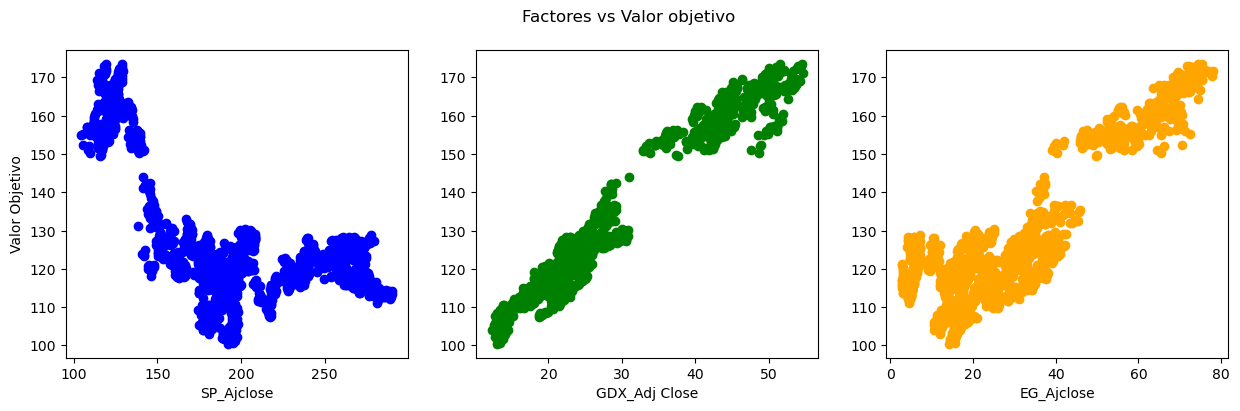

In [70]:
print("Descripción estadística:")
print(datos_seleccionados.describe())

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].scatter(datos_seleccionados[datos1], datos_seleccionados[objetivo0], color='blue')
axs[0].set_xlabel(datos1)
axs[0].set_ylabel(objetivo0)

axs[1].scatter(datos_seleccionados[datos2], datos_seleccionados[objetivo0], color='green')
axs[1].set_xlabel(datos2)

axs[2].scatter(datos_seleccionados[datos3], datos_seleccionados[objetivo0], color='orange')
axs[2].set_xlabel(datos3)

plt.suptitle("Factores vs Valor objetivo")
plt.show()

In [71]:
# Armado del modelo

X = datos_seleccionados[[datos1, datos2, datos3]]
y = datos_seleccionados[objetivo0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

y_pred_multiple = model_multiple.predict(X_test)

Intercepto: 86.48229840424753
Coeficientes: [-0.01412419  1.6796173  -0.00248266]

Evaluación del modelo (Regresión Múltiple):
MAE: 2.685182897526746
MSE: 13.31486359779755
R²: 0.9553274613325824
Varianza explicada: 0.9556487156756666



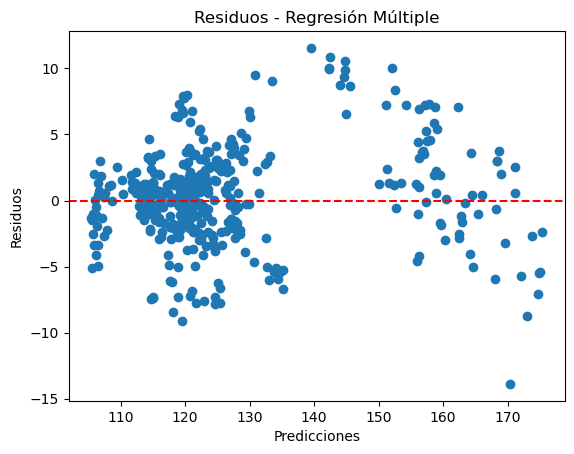

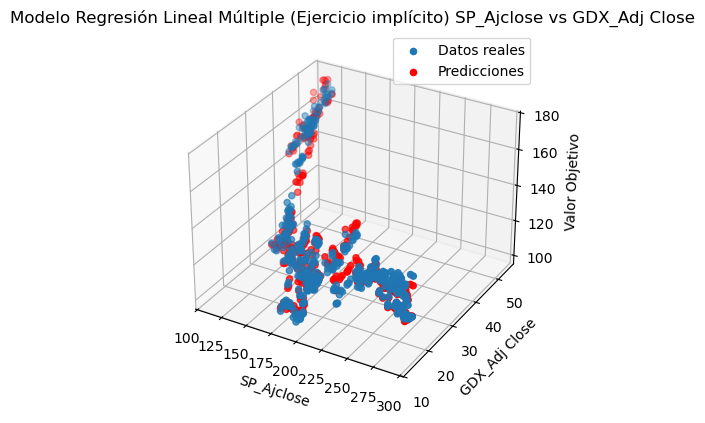

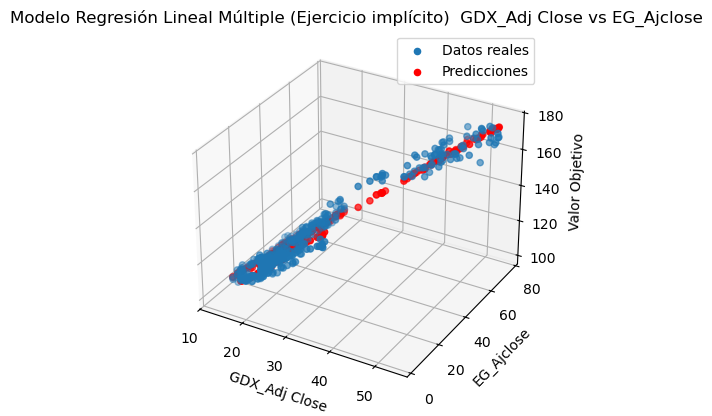

In [72]:
print("Intercepto:", model_multiple.intercept_)
print("Coeficientes:", model_multiple.coef_)

print("\nEvaluación del modelo (Regresión Múltiple):")
print("MAE:", mean_absolute_error(y_test, y_pred_multiple))
print("MSE:", mean_squared_error(y_test, y_pred_multiple))
print("R²:", r2_score(y_test, y_pred_multiple))
print("Varianza explicada:", explained_variance_score(y_test, y_pred_multiple))

print()

residuos = y_test - y_pred_multiple
plt.scatter(y_pred_multiple, residuos)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos - Regresión Múltiple")
plt.show()

print()

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test[datos1], X_test[datos2], y_test, label="Datos reales")
ax.scatter(X_test[datos1], X_test[datos2], y_pred_multiple, color='red', label="Predicciones")
ax.set_xlabel(datos1)
ax.set_ylabel(datos2)
ax.set_zlabel(objetivo0)
plt.title(f"Modelo Regresión Lineal Múltiple (Ejercicio implícito) {datos1} vs {datos2}")
plt.legend()
plt.show()

print()

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test[datos2], X_test[datos3], y_test, label="Datos reales")
ax.scatter(X_test[datos2], X_test[datos3], y_pred_multiple, color='red', label="Predicciones")
ax.set_xlabel(datos2)
ax.set_ylabel(datos3)
ax.set_zlabel(objetivo0)
plt.title(f"Modelo Regresión Lineal Múltiple (Ejercicio implícito)  {datos2} vs {datos3}")
plt.legend()
plt.show()